In [1]:
from datasets import load_dataset

ds = load_dataset(
    "flakoash/babylm-curriculum-sliding-window-4bands",
    split="train",
    streaming=True,
)

for i, row in enumerate(ds):
    print(row)
    if i >= 9:
        break

/Users/elizabethgranda/Documents/babylm/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'id': 'open_subtitles.train#192179', 'text': 'She looks happy now, but if I was married to her for eight years,'}
{'id': 'open_subtitles.train#161573', 'text': "I don't want to hurt you, Amy."}
{'id': 'childes.train#376300', 'text': 'hey you got T jeez.'}
{'id': 'open_subtitles.train#161658', 'text': 'Clean and polish all fixtures.'}
{'id': 'bnc_spoken.train#42878', 'text': 'I never use a hair dryer any more.'}
{'id': 'childes.train#146375', 'text': 'well you can make them  jump up there right by themselves.'}
{'id': 'childes.train#421729', 'text': "who's in there?"}
{'id': 'childes.train#483315', 'text': 'she looking at you.'}
{'id': 'childes.train#481698', 'text': "in Mommy's room."}
{'id': 'open_subtitles.train#358537', 'text': 'I did not mean to be disrespectful .'}


In [ ]:
from itertools import islice

# Grab rows at positions 0, 25%, 50%, 75% of the dataset
# First we need the total count
print("Counting total rows (this may take a minute)...")
total = sum(1 for _ in ds)
print(f"Total rows: {total}")
print(f"Each band is roughly: {total // 4} rows")
print(f"Overlap zone between bands: ~{total // 16} rows")

Counting total rows (this may take a minute)...
Total rows: 1452016
Each band is roughly: 363004 rows
Overlap zone between bands: ~90751 rows


In [3]:
from datasets import load_dataset

for epoch in range(4):
    ds = load_dataset(
        "flakoash/babylm-curriculum-sliding-window-4bands",
        data_files=f"curriculum/epoch_0{epoch}.jsonl",
        split="train",
        streaming=True,
    )
    
    # Sample 3 rows to compare across bands
    print(f"\n── epoch_{epoch:02d} (Band {epoch+1}) ──")
    for i, row in enumerate(ds):
        print(row)
        if i >= 2:
            break


── epoch_00 (Band 1) ──
{'id': 'open_subtitles.train#192179', 'text': 'She looks happy now, but if I was married to her for eight years,'}
{'id': 'open_subtitles.train#161573', 'text': "I don't want to hurt you, Amy."}
{'id': 'childes.train#376300', 'text': 'hey you got T jeez.'}

── epoch_01 (Band 2) ──
{'id': 'childes.train#362440', 'text': 'started to like.'}
{'id': 'open_subtitles.train#325970', 'text': "Following the announcement, many people didn't go to work."}
{'id': 'childes.train#146988', 'text': "'cause I'm finished."}

── epoch_02 (Band 3) ──
{'id': 'childes.train#457696', 'text': "that's a little snowman."}
{'id': 'childes.train#126660', 'text': 'that night he had a stomachache.'}
{'id': 'childes.train#420708', 'text': "or will they tickle your brother if they don't see your Popeye shirt?"}

── epoch_03 (Band 4) ──
{'id': 'open_subtitles.train#343489', 'text': "Ask her yourself why she's doing this"}
{'id': 'childes.train#352211', 'text': 'and to the parade?'}
{'id': 'chi

In [1]:
from datasets import load_dataset

ds = load_dataset(
    "deru35/only_weebit",
    split="train",
    streaming=True,
)

for i, row in enumerate(ds):
    print(row)
    if i >= 9:
        break

/Users/druiz35/Documents/factored_research/CLRYS/BabyLM2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'complexity_age_interval': 1, 'text': "Chaille Stovall is making a movie about the 2000 presidential election.\nHis friend Zac Skipp is helping him.\nChaille (pronounced shal-ee) is only 11 years old!\nis the name of Chaille Stovall's latest movie.\nThe movie is about the 2000 presidential election.\nFor the movie, Chaille talked to the two main candidates.\nHe talked to Texas Governor George W. Bush at the governor's home.\nChaille also traveled with Vice President Al Gore on his campaign bus.\nChaille has been making films since he was 8 years old.\nChaille's first movie was\nThe movie explored what people think about boy ballet dancers.\nChaille won two awards for the movie.\nChaille has also made movies about religion, how kids cope with pain, and musicians.\nHow did you get started making movies?\nThen people at HBO [a cable TV company] saw it, and they said they wanted to show the film.\nHow do you decide what your movies will be about?\nI just take stuff that's a part of everyd

## Only_weebit

In [ ]:
dataset_name = "deru35/only_weebit"
def get_text_from_example(example):
    if isinstance(example, dict):
        for key in ("text", "sentence", "article", "content"):
            value = example.get(key)
            if isinstance(value, str):
                return value
        for value in example.values():
            if isinstance(value, str):
                return value
    return str(example)

ds_all = load_dataset(dataset_name, split="all")

total_words = 0
unique_words = set()
if isinstance(ds_all, dict):
    for split_name, split_ds in ds_all.items():
        split_words = 0
        for example in split_ds:
            text = get_text_from_example(example)
            split_words += len(text.split())
        print(f"{split_name}: {split_words} words")
        total_words += split_words
else:
    split_words = 0
    for example in ds_all:
        text = get_text_from_example(example)
        split_words += len(text.split())
        unique_words.update(text.split())
    print(f"single split: {split_words} words")
    total_words = split_words

print("Total words across all splits:", total_words)
print("Unique words:", len(unique_words))

single split: 757586 words
Total words across all splits: 757586
Unique words: 51771


In [23]:
import pandas as pd

data = pd.read_csv("/Users/elizabethgranda/Documents/BabyLM2026/babylm_cl_rys/CL2_experiments/rys_gunning_fog/rys_fast_summary_CL2_gunning_fog.csv")
data.head()

,rys_start,rys_end,duplicated_layers,execution_layers,blimp_fast,supplement_fast,ewok_fast,entity_tracking_fast,combined_sentence_acc,eye_tracking_score,self_paced_reading_score,output_dir
0,0,0,0,12,62.85,57.2,52.00,16.62,47.1675,0.49,0.01,results_rys_fast/baseline
1,0,1,1,13,61.58,56.0,50.64,15.94,46.0400,0.23,0.03,results_rys_fast/rys_0_1
2,0,2,2,14,61.63,55.2,51.18,16.58,46.1475,0.28,0.01,results_rys_fast/rys_0_2
3,1,2,1,13,62.85,56.4,49.45,16.10,46.2000,0.49,0.01,results_rys_fast/rys_1_2
4,0,3,3,15,61.30,54.8,49.45,16.15,45.4250,0.31,0.01,results_rys_fast/rys_0_3


In [24]:
data.loc[(data["rys_start"] == 2) & (data["rys_end"] == 7)]

,rys_start,rys_end,duplicated_layers,execution_layers,blimp_fast,supplement_fast,ewok_fast,entity_tracking_fast,combined_sentence_acc,eye_tracking_score,self_paced_reading_score,output_dir
24,2,7,5,17,62.22,59.6,49.09,15.82,46.6825,0.57,0.0,results_rys_fast/rys_2_7


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


def make_rys_matrix(df: pd.DataFrame, metric: str = "combined_sentence_acc", use_delta: bool = True,):
    df = df.copy()

    # get baseline row: original model, no repeated layers.
    baseline_rows = df[(df["rys_start"] == 0) & (df["rys_end"] == 0)]
    if len(baseline_rows) == 0:
        raise ValueError("No baseline row found: expected rys_start=0 and rys_end=0")

    baseline_value = baseline_rows.iloc[0][metric]

    rys = df[~((df["rys_start"] == 0) & (df["rys_end"] == 0))].copy()

    if use_delta:
        value_col = f"delta_{metric}"
        rys[value_col] = rys[metric] - baseline_value
    else:
        value_col = metric

    original_n_layers = int(
        baseline_rows.iloc[0]["execution_layers"]
    )
    matrix = np.full((original_n_layers, original_n_layers + 1), np.nan)

    for _, row in rys.iterrows():
        i = int(row["rys_start"])
        j = int(row["rys_end"])

        if 0 <= i < original_n_layers and 0 <= j <= original_n_layers:
            matrix[i, j] = row[value_col]

    return matrix, baseline_value, value_col


def plot_rys_brain_scanner(
    df: pd.DataFrame,
    metric: str = "combined_sentence_acc",
    use_delta: bool = True,
    title: str | None = None,
    output_path: str | Path | None = None,
    annotate: bool = True,
):
    matrix, baseline_value, value_col = make_rys_matrix(
        df=df,
        metric=metric,
        use_delta=use_delta,
    )

    n_layers = matrix.shape[0]

    best_flat_idx = np.nanargmax(matrix)
    best_i, best_j = np.unravel_index(best_flat_idx, matrix.shape)
    best_value = matrix[best_i, best_j]

    if use_delta:
        vmax = np.nanmax(np.abs(matrix))
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        cmap = "RdBu_r"
        colorbar_label = f"{metric} delta vs baseline"
    else:
        norm = None
        cmap = "viridis"
        colorbar_label = metric

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(
        matrix,
        origin="upper",      # important: layer 0 at top, like the blog
        aspect="auto",
        cmap=cmap,
        norm=norm,
    )

    if title is None:
        if use_delta:
            title = f"BabyLM GPT-2 Strict Small: {metric} Delta vs Baseline"
        else:
            title = f"BabyLM GPT-2 Strict Small: {metric}"

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("j (end)")
    ax.set_ylabel("i (start)")

    ax.set_xticks(range(0, n_layers + 1))
    ax.set_yticks(range(0, n_layers))

    # Green circle around best cell.
    ax.scatter(
        best_j,
        best_i,
        s=250,
        facecolors="none",
        edgecolors="lime",
        linewidths=3,
        label=f"Best ({best_i}, {best_j})",
    )

    ax.legend(loc="upper right")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                if not np.isnan(matrix[i, j]):
                    ax.text(
                        j,
                        i,
                        f"{matrix[i, j]:.2f}",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="black",
                    )

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=250, bbox_inches="tight")

    print("Baseline:", baseline_value)
    print("Best RYS config:")
    print(f"  rys_start = {best_i}")
    print(f"  rys_end   = {best_j}")
    print(f"  repeated layers = [{best_i}, {best_j})")
    print(f"  {value_col} = {best_value:.4f}")

    return matrix, fig, ax

Baseline: 47.1675
Best RYS config:
  rys_start = 6
  rys_end   = 8
  repeated layers = [6, 8)
  delta_combined_sentence_acc = 0.3425


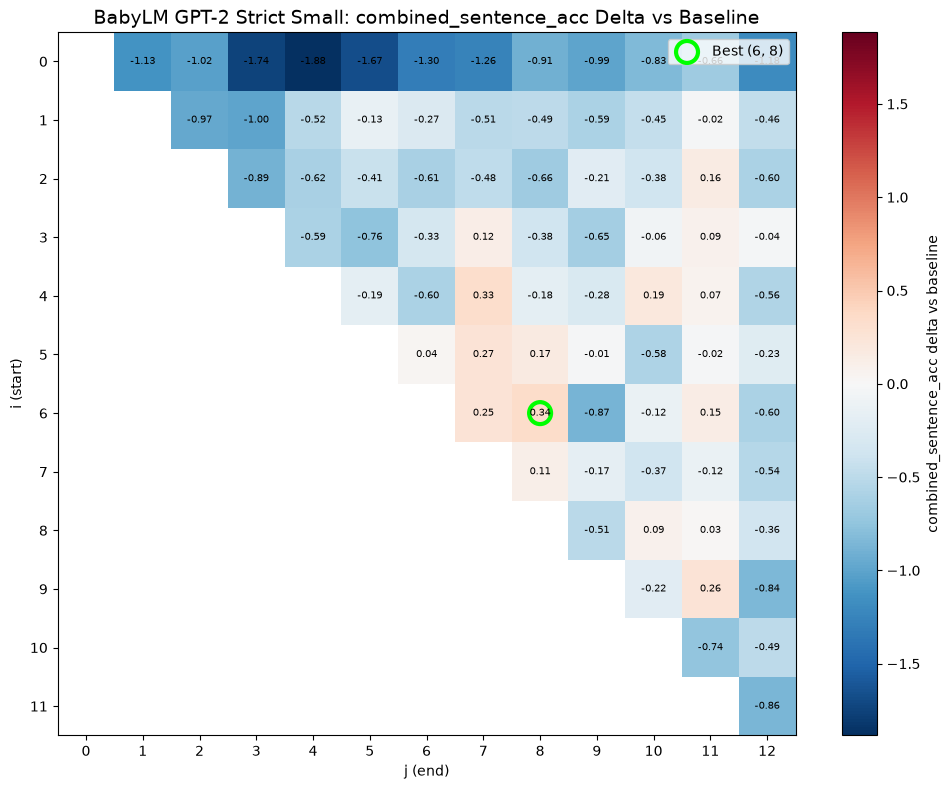

In [26]:
matrix, fig, ax = plot_rys_brain_scanner(
    data,
    metric="combined_sentence_acc",
    use_delta=True,
    output_path="results_rys_fast/heatmaps/combined_sentence_acc_delta_brain_scanner.png",
    annotate=True,
)

Baseline: 62.85
Best RYS config:
  rys_start = 8
  rys_end   = 11
  repeated layers = [8, 11)
  delta_blimp_fast = 0.9900
Baseline: 57.2
Best RYS config:
  rys_start = 4
  rys_end   = 7
  repeated layers = [4, 7)
  delta_supplement_fast = 3.2000
Baseline: 52.0
Best RYS config:
  rys_start = 6
  rys_end   = 8
  repeated layers = [6, 8)
  delta_ewok_fast = 0.2700
Baseline: 16.62
Best RYS config:
  rys_start = 5
  rys_end   = 11
  repeated layers = [5, 11)
  delta_entity_tracking_fast = 0.3000
Baseline: 47.1675
Best RYS config:
  rys_start = 6
  rys_end   = 8
  repeated layers = [6, 8)
  delta_combined_sentence_acc = 0.3425
Baseline: 0.49
Best RYS config:
  rys_start = 2
  rys_end   = 12
  repeated layers = [2, 12)
  delta_eye_tracking_score = 0.2000
Baseline: 0.01
Best RYS config:
  rys_start = 4
  rys_end   = 12
  repeated layers = [4, 12)
  delta_self_paced_reading_score = 0.0300


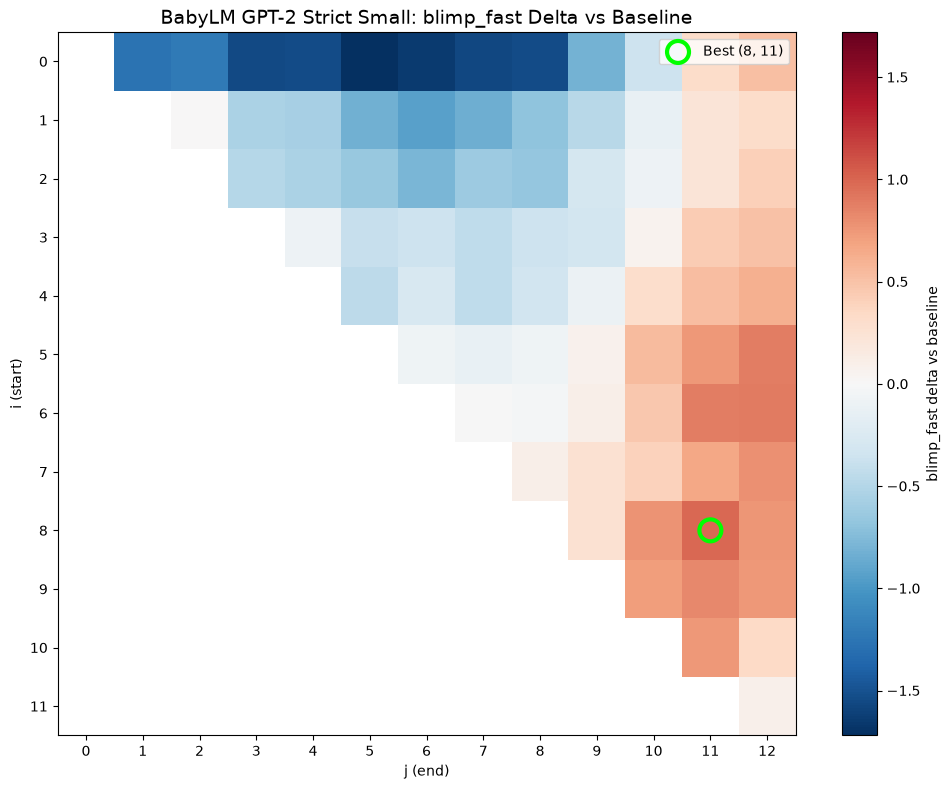

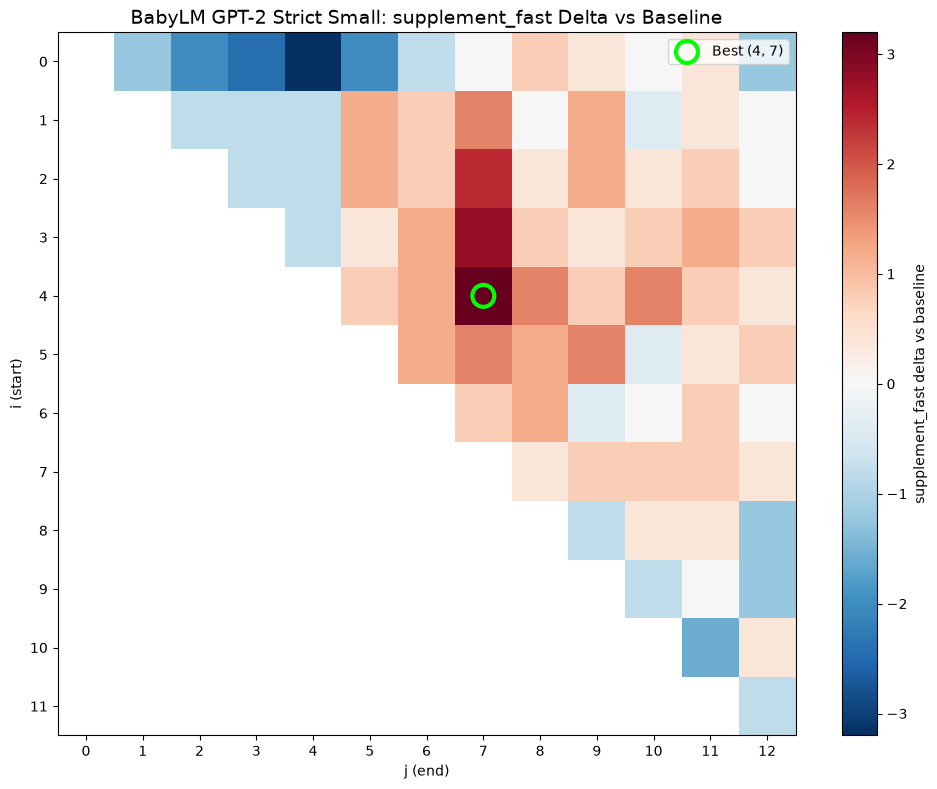

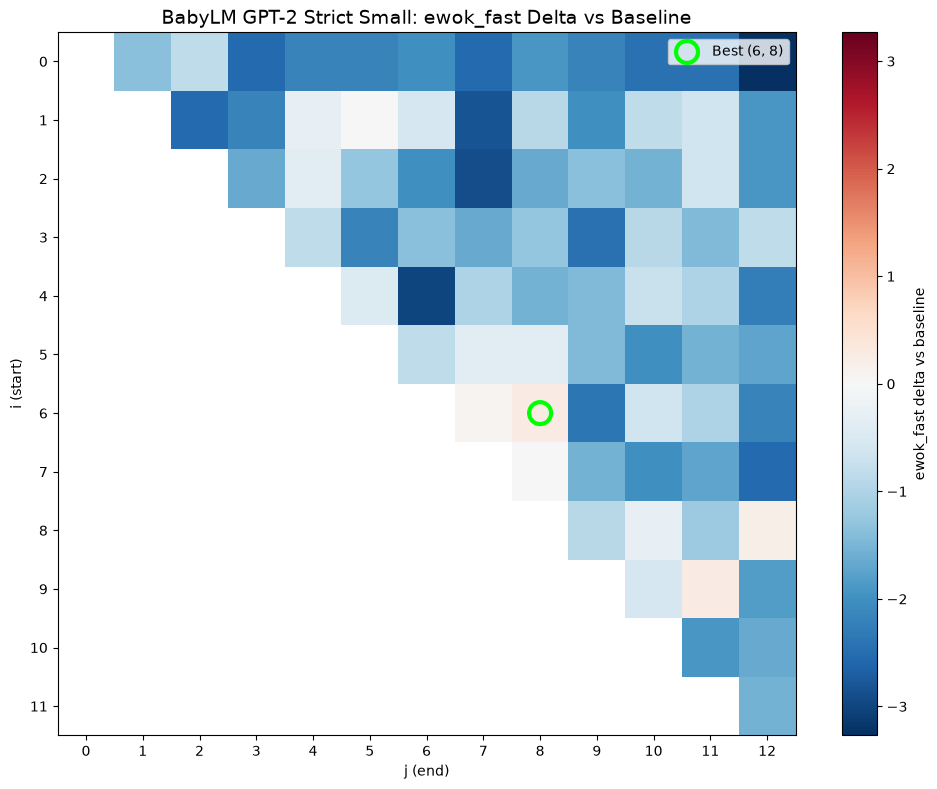

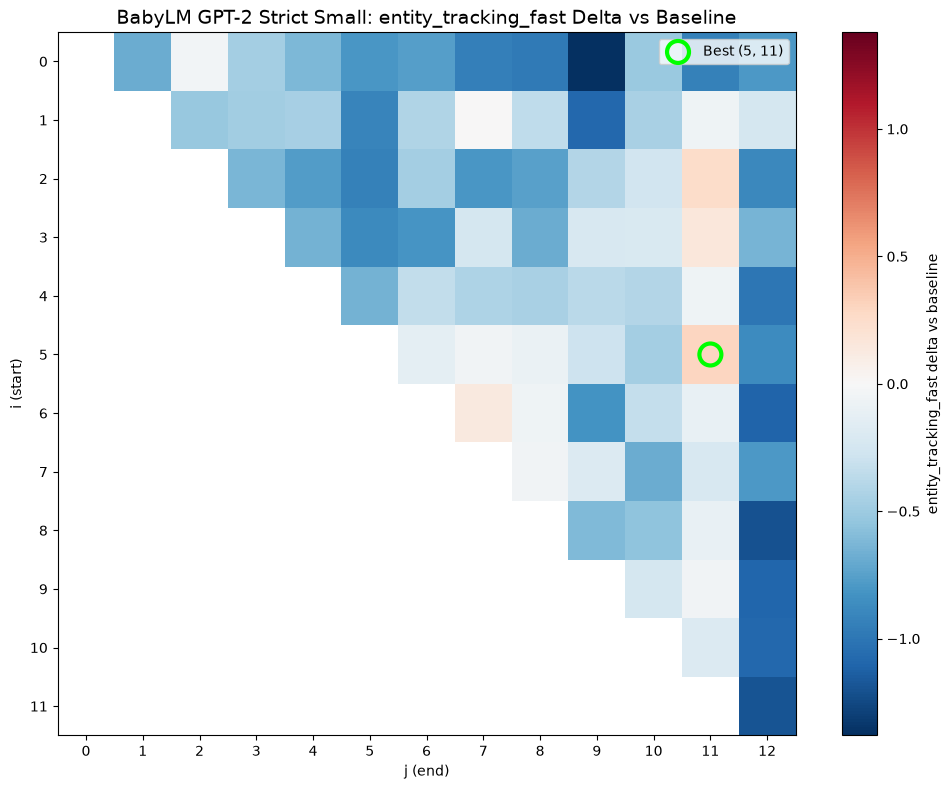

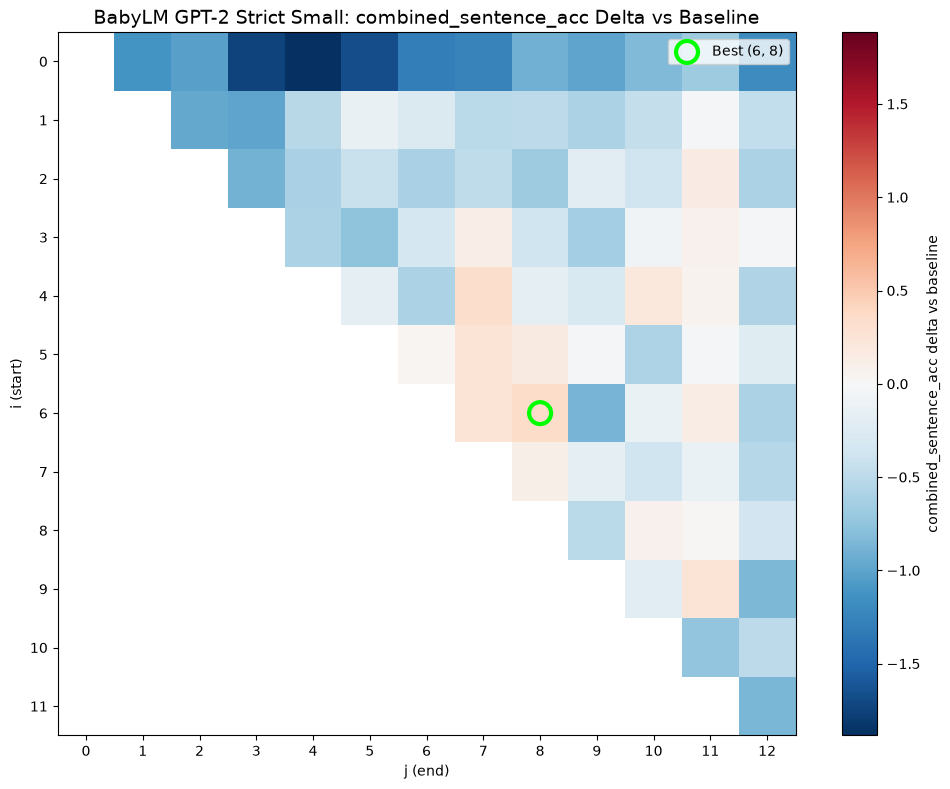

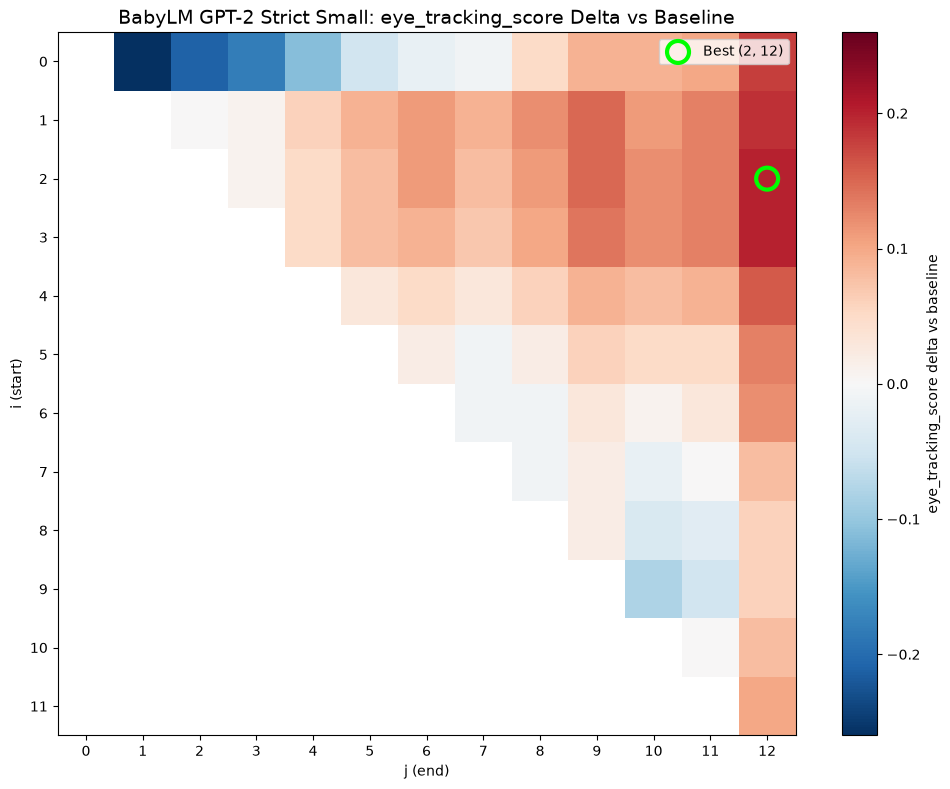

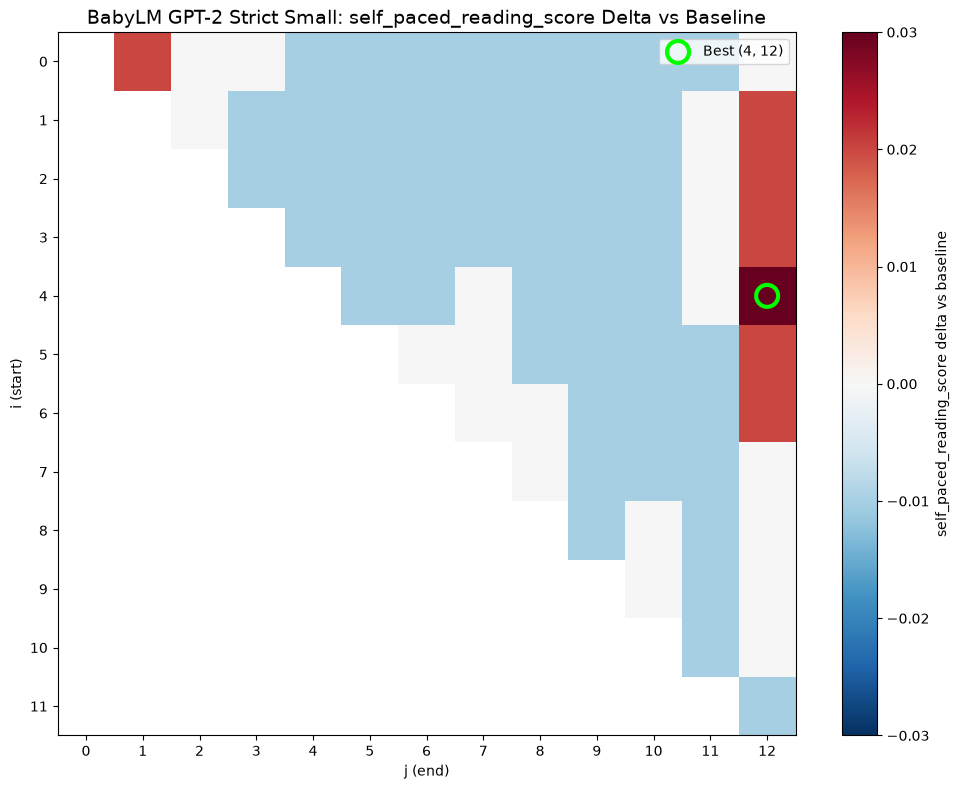

In [27]:
for metric in [
    "blimp_fast",
    "supplement_fast",
    "ewok_fast",
    "entity_tracking_fast",
    "combined_sentence_acc",
    "eye_tracking_score",
    "self_paced_reading_score",
]:
    plot_rys_brain_scanner(
        data,
        metric=metric,
        use_delta=True,
        output_path=f"results_rys_fast/heatmaps/{metric}_delta_brain_scanner.png",
        annotate=False,
    )

In [28]:
baseline = data[(data["rys_start"] == 0) & (data["rys_end"] == 0)].iloc[0]

ranked = data[~((data["rys_start"] == 0) & (data["rys_end"] == 0))].copy()
ranked["delta_combined_sentence_acc"] = (
    ranked["combined_sentence_acc"] - baseline["combined_sentence_acc"]
)

ranked = ranked.sort_values("delta_combined_sentence_acc", ascending=False)

ranked[
    [
        "rys_start",
        "rys_end",
        "duplicated_layers",
        "combined_sentence_acc",
        "delta_combined_sentence_acc",
        "blimp_fast",
        "supplement_fast",
        "ewok_fast",
        "entity_tracking_fast",
        "eye_tracking_score",
        "self_paced_reading_score",
    ]
].head(20)

,rys_start,rys_end,duplicated_layers,combined_sentence_acc,delta_combined_sentence_acc,blimp_fast,supplement_fast,ewok_fast,entity_tracking_fast,eye_tracking_score,self_paced_reading_score
35,6,8,2,47.5100,0.3425,62.81,58.4,52.27,16.56,0.48,0.01
26,4,7,3,47.5000,0.3325,62.41,60.4,51.00,16.19,0.52,0.01
27,5,7,2,47.4325,0.2650,62.72,58.8,51.64,16.57,0.48,0.01
65,9,11,2,47.4275,0.2600,63.67,57.2,52.27,16.57,0.44,0.00
28,6,7,1,47.4200,0.2525,62.84,58.0,52.09,16.75,0.48,0.01
50,4,10,6,47.3600,0.1925,63.15,58.8,51.27,16.22,0.57,0.00
34,5,8,3,47.3375,0.1700,62.78,58.4,51.64,16.53,0.51,0.00
58,2,11,9,47.3250,0.1575,63.07,58.0,51.36,16.87,0.62,0.01
62,6,11,5,47.3125,0.1450,63.73,58.0,51.00,16.52,0.52,0.00
25,3,7,4,47.2875,0.1200,62.41,60.0,50.36,16.38,0.56,0.00
